# Check Boosting Models

Evaluating Boosting Models...

                Model       MAE       MSE  R2 Score  CV R2 Mean  CV R2 Std
2            XGBoost  0.073359  0.007769  0.904935    0.874201   0.009033
4           CatBoost  0.074529  0.008055  0.901439    0.866608   0.012390
3           LightGBM  0.076976  0.008901  0.891087    0.860895   0.007247
0  Gradient Boosting  0.112509  0.021665  0.734914    0.723821   0.031894
1           AdaBoost  0.189982  0.045430  0.444125    0.466274   0.032230


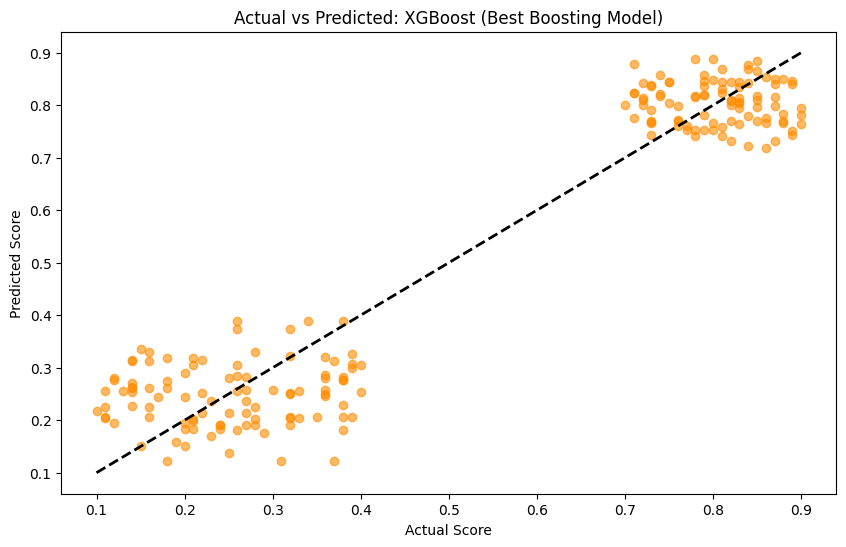

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modern Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Load data and remove duplicates
df = pd.read_csv('/content/heart.csv')
df_unique = df.drop_duplicates()

X = df_unique.drop('target', axis=1)
y = df_unique['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the full suite of boosting models
boosting_models = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

results = []

print("Evaluating Boosting Models...")
for name, model in boosting_models.items():
    # Fit and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate standard metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross Validation (Stability check)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2 Score": r2,
        "CV R2 Mean": cv_scores.mean(),
        "CV R2 Std": cv_scores.std()
    })

# Compare and Sort Results
results_df = pd.DataFrame(results).sort_values(by='CV R2 Mean', ascending=False)
print("\n", results_df)

# Plotting the leader
best_model_name = results_df.iloc[0]['Model']
best_model = boosting_models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'Actual vs Predicted: {best_model_name} (Best Boosting Model)')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.show()

# Check for Overfitting

Computing learning curve for Gradient Boosting...
Computing learning curve for AdaBoost...
Computing learning curve for XGBoost...
Computing learning curve for LightGBM...
Computing learning curve for CatBoost...


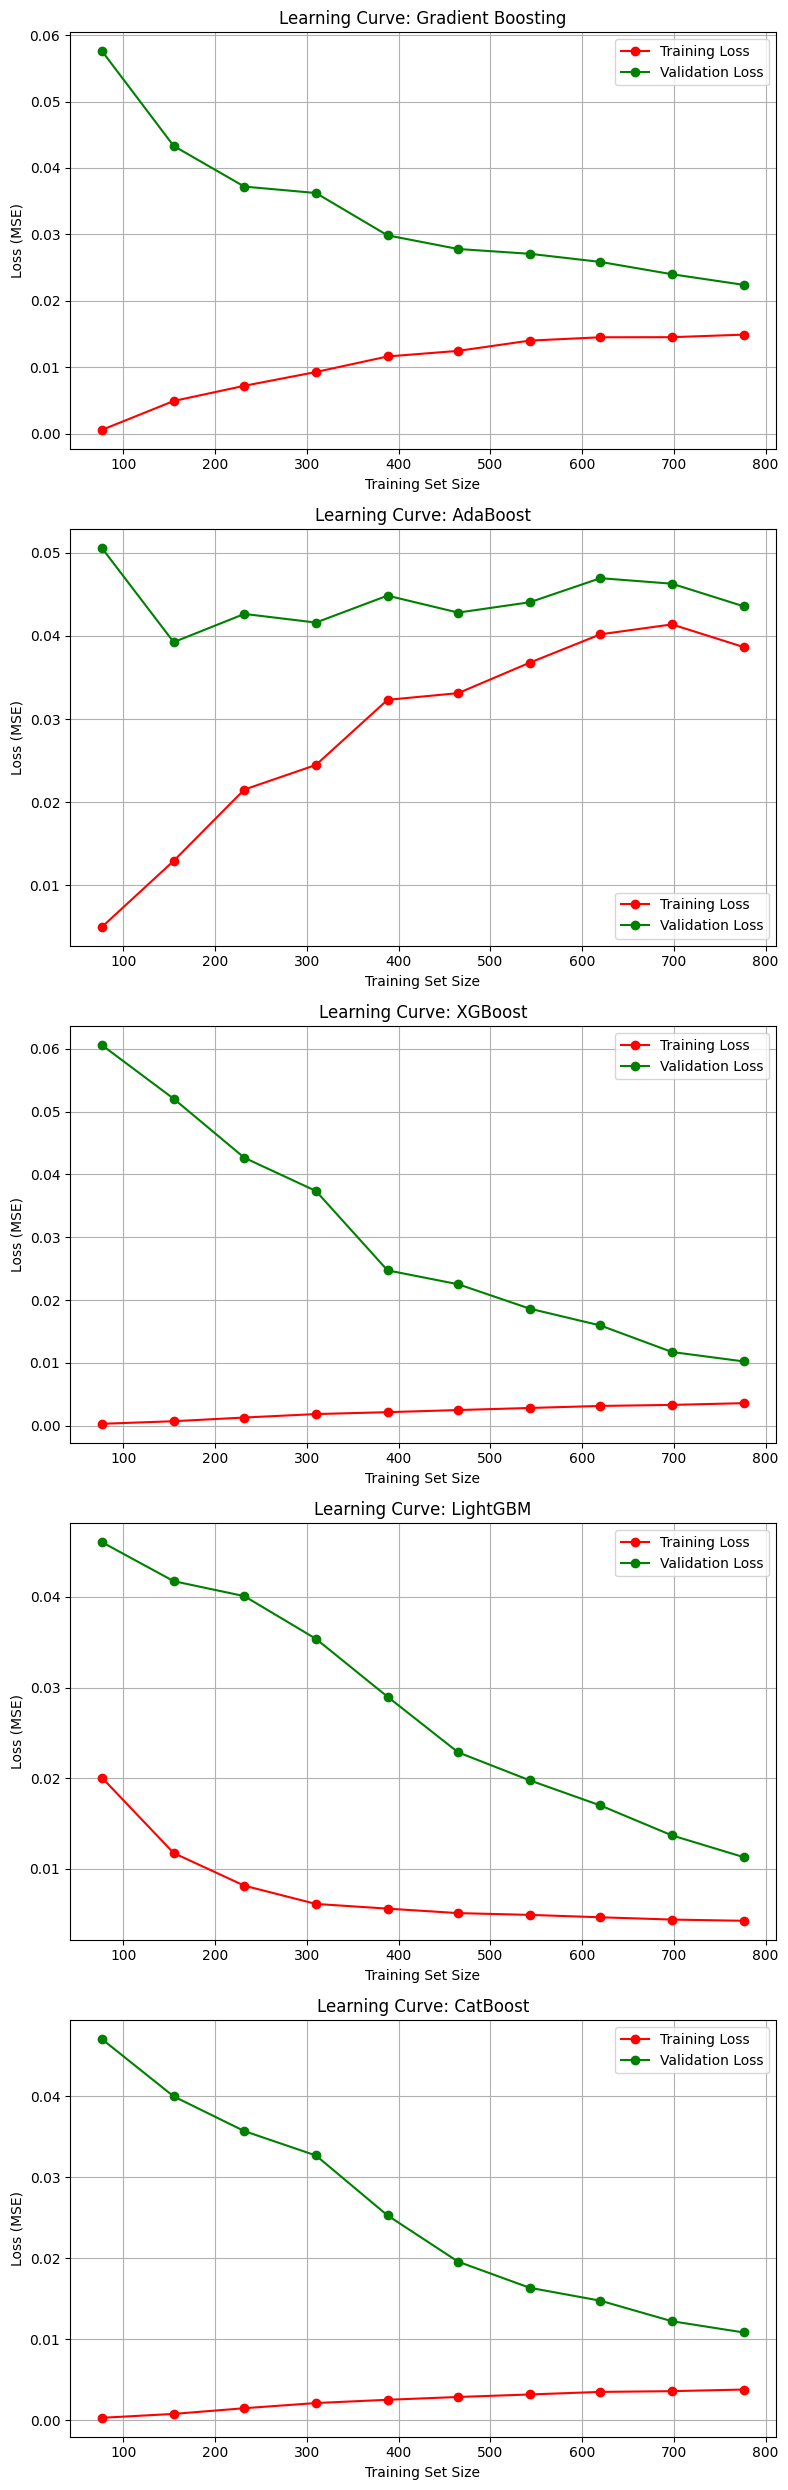

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Load data
df = pd.read_csv('/content/heart.csv')
df_unique = df.drop_duplicates()
X = df_unique.drop('target', axis=1)
y = df_unique['target']

# Define models
models = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

def plot_learning_curves(models, X, y):
    n_models = len(models)
    fig, axes = plt.subplots(nrows=n_models, ncols=1, figsize=(8, 5 * n_models))

    if n_models == 1: axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        print(f"Computing learning curve for {name}...")

        # Calculate learning curve data
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='neg_mean_squared_error'
        )

        # Convert Negative MSE to positive Loss
        train_loss = -np.mean(train_scores, axis=1)
        test_loss = -np.mean(test_scores, axis=1)

        # Plotting
        ax.plot(train_sizes, train_loss, 'o-', color="r", label="Training Loss")
        ax.plot(train_sizes, test_loss, 'o-', color="g", label="Validation Loss")
        ax.set_title(f"Learning Curve: {name}")
        ax.set_xlabel("Training Set Size")
        ax.set_ylabel("Loss (MSE)")
        ax.legend(loc="best")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(models, X, y)

# Hyperparameter tuning

Tuning XGBoost...
Tuning CatBoost...


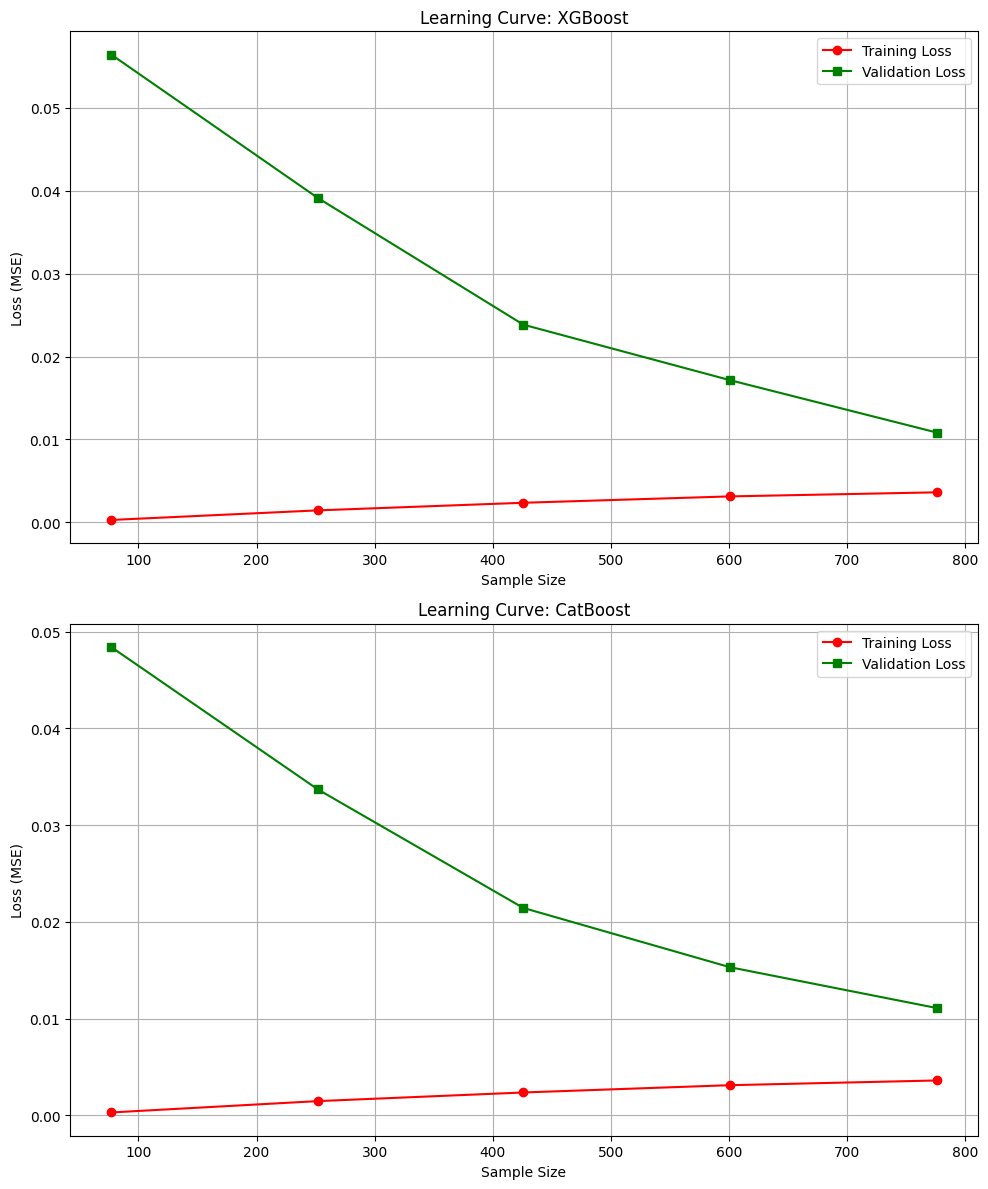

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Load dataset
df = pd.read_csv('heart.csv').drop_duplicates()
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Define Parameter Grids
xgb_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

cat_grid = {
    'iterations': [200, 500],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6, 10],
    'l2_leaf_reg': [1, 3, 5]
}

# 2. Hyperparameter Tuning
print("Tuning XGBoost...")
xgb_search = RandomizedSearchCV(XGBRegressor(random_state=42), xgb_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error')
xgb_search.fit(X_train, y_train)

print("Tuning CatBoost...")
cat_search = RandomizedSearchCV(CatBoostRegressor(random_state=42, verbose=0), cat_grid, n_iter=10, cv=3, scoring='neg_mean_squared_error')
cat_search.fit(X_train, y_train)

best_models = {"XGBoost": xgb_search.best_estimator_, "CatBoost": cat_search.best_estimator_}

# 3. Plot Learning Curves
fig, axes = plt.subplots(2, 1, figsize=(10, 12))
for i, (name, model) in enumerate(best_models.items()):
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_squared_error'
    )

    # Convert Neg MSE to positive Loss
    train_loss = -np.mean(train_scores, axis=1)
    val_loss = -np.mean(test_scores, axis=1)

    axes[i].plot(train_sizes, train_loss, 'o-', color='r', label='Training Loss')
    axes[i].plot(train_sizes, val_loss, 's-', color='g', label='Validation Loss')
    axes[i].set_title(f'Learning Curve: {name}')
    axes[i].set_xlabel('Sample Size')
    axes[i].set_ylabel('Loss (MSE)')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# Saving Models

In [6]:
import joblib
import os

# Create a directory to store models
os.makedirs('models', exist_ok=True)

# 1. Saving XGBoost
xgb_filename = 'models/best_xgb_model.joblib'
joblib.dump(best_models['XGBoost'], xgb_filename)
print(f"XGBoost model saved to: {xgb_filename}")

# 2. Saving CatBoost
cat_filename = 'models/best_catboost_model.cbm'
best_models['CatBoost'].save_model(cat_filename, format="cbm")
print(f"CatBoost model saved to: {cat_filename}")

XGBoost model saved to: models/best_xgb_model.joblib
CatBoost model saved to: models/best_catboost_model.cbm


# Testing

In [8]:
import pandas as pd
import joblib
from catboost import CatBoostRegressor

# 1. Define your custom patient data
custom_patient = {
    'age': 58,
    'sex': 1,
    'cp': 2,
    'trestbps': 130,
    'chol': 250,
    'fbs': 0,
    'restecg': 1,
    'thalach': 155,
    'exang': 0,
    'oldpeak': 1.2,
    'slope': 1,
    'ca': 0,
    'thal': 2
}

# Convert to DataFrame
custom_df = pd.DataFrame([custom_patient])

# 2. Load and Predict with XGBoost
try:
    xgb_model = joblib.load('models/best_xgb_model.joblib')
    xgb_score = xgb_model.predict(custom_df)[0]
    print(f"XGBoost Predicted Risk Score: {1 - xgb_score:.4f}")
except Exception as e:
    print(f"XGBoost Error: {e}")

# 3. Load and Predict with CatBoost
try:
    cat_model = CatBoostRegressor()
    cat_model.load_model('models/best_catboost_model.cbm')
    cat_score = cat_model.predict(custom_df)[0]
    print(f"CatBoost Predicted Risk Score: {1 - cat_score:.4f}")
except Exception as e:
    print(f"CatBoost Error: {e}")

XGBoost Predicted Risk Score: 0.4605
CatBoost Predicted Risk Score: 0.3429
